In [1]:
import numpy as np
import spin_hamiltonian as spin
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
import matplotlib.colors as clr
from qil_helpers.Ben import General as Ben

from IPython.display import display, Latex
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot
from pathos.multiprocessing import ProcessingPool as Pool


In [2]:
pts=50
r=100
thetas=np.tile(np.linspace(0,np.pi,pts),pts)
phis=np.repeat(np.linspace(0,2*np.pi,pts),pts)

# x=r*np.outer(np.sin(thetas),np.cos(phis))
# y=r*np.outer(np.sin(thetas),np.sin(phis))
# z=r*np.outer(np.ones(np.size(phis)),np.cos(thetas))
x=r*np.sin(thetas)*np.cos(phis)
y=r*np.sin(thetas)*np.sin(phis)
z=r*np.cos(thetas)
vec=np.vstack([x,y,z])
direction=np.array([1,1,1])
#idx=np.squeeze(np.where(np.dot(direction,vec)>=0))
idx=np.arange(0,vec.shape[-1],1)
vec=vec[:,idx]


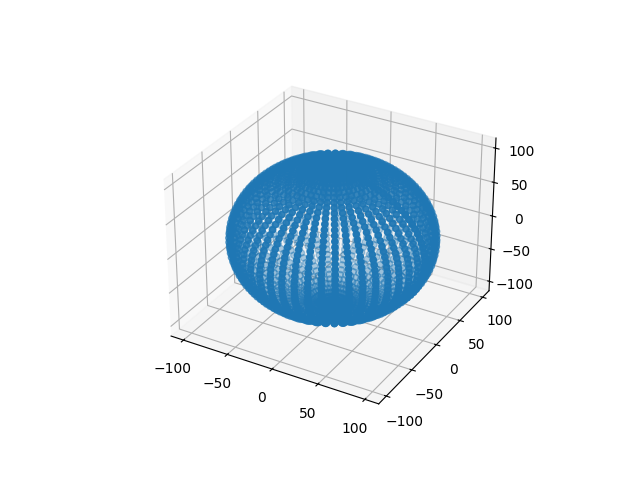

In [3]:
%matplotlib widget
#%matplotlib inline

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*vec)
#ax.plot_surface(x,y,z)
#ax.scatter(*bsph.T)
plt.show()


In [4]:
ground=spin.hamilFromYAML("./ion_params/Er_YSO_site1_ground.yml",IOveride=7/2)
excited=spin.hamilFromYAML("./ion_params/Er_YSO_site1_excited.yml",IOveride=7/2)
ground=excited
Hcalc=lambda B,self: self.electronicZeeman(B)#+self.nuclearZeeman(B)+self.HHF+self.HQP
ground.Hfunc=Hcalc
excited.Hfunc=Hcalc

Ag=ground.genAMatrix(spin.muB*ground.gE,ground.S,electronic=True)
Ae=excited.genAMatrix(spin.muB*excited.gE,excited.S,electronic=True)


{'Spin': {'Espin': '1/2', 'Ispin': '7/2'}, 'Hyperfine': {'A': 'np.matrix([[304.8,-252.8,-307.6],[-252.8,778.0,710.2],[-307.6,710.2,616.2]])*1e6*h', 'A_rot': 'np.array([0,0,0])'}, 'Quadrupole': {'Q': 'np.matrix([[10.1,-10.1,-14.0],[-10.1,-6.3,-15.2],[-14.0,-15.6,-3.8]])*1e6*h', 'Q_rot': 'np.array([0,0,0])'}, 'E_Zeeman': {'g': 'np.matrix([[2.85,-2.98,-3.63],[-2.98,9.00,5.51],[3.63,5.51,5.19]])', 'g_rot': 'np.array([0,0,0])'}, 'N_Zeeman': {'mu': '-0.56'}, 'Oscillator': {'par': 'np.block([[np.eye(odim),np.zeros([odim,odim])],[np.zeros([odim,odim]),np.eye(odim)]])', 'perp': 'np.block([[np.zeros([odim,odim]),1*np.eye(odim)],[np.eye(odim),np.zeros([odim,odim])]])', 'perp_T': 'np.block([[np.zeros([odim,odim]),1j*np.eye(odim)],[-1j*np.eye(odim),np.zeros([odim,odim])]])'}}
{'Spin': {'Espin': '1/2', 'Ispin': '7/2'}, 'Hyperfine': {'A': 'np.matrix([[307.9,-327.5,-464.8],[-327.5,607.8,676.7],[-464.8,676.7,980.5]])*1e6*h', 'A_rot': 'np.array([0,0,0])'}, 'Quadrupole': {'Q': 'np.matrix([[56.0,1.66,5.80

In [5]:
def multiSweepOptical(Bs):
    FSG=np.zeros((len(Bs),ground.dim))
    FSE=np.zeros((len(Bs),excited.dim))


    FpG=np.zeros((len(Bs),ground.dim,3))
    FpE=np.zeros((len(Bs),ground.dim,3))

    #if __name__ == '__main__':
    with Pool() as pool:
        #F,Fp,Fpp=pool.map(ground.calcBOptParams,Bs)
        for i,result in enumerate(pool.map(ground.calcBOptParams,Bs)):#range(Bs.shape[0]):
            FSG[i,:],FpG[i,:,:],_=result

        for i,result in enumerate(pool.map(excited.calcBOptParams,Bs)):#range(Bs.shape[0]):
            FSE[i,:],FpE[i,:,:],_=result

    return spin.eachElemFunc(FSG,FSE,ax=1),spin.eachElemFunc(FpG,FpE,ax=1)


In [6]:
T,Td=multiSweepOptical(vec.T)


C:\Users\neb16\AppData\Local\Temp/ipykernel_27348/3162183674.py:13: ComplexWarning:

Casting complex values to real discards the imaginary part

C:\Users\neb16\AppData\Local\Temp/ipykernel_27348/3162183674.py:16: ComplexWarning:

Casting complex values to real discards the imaginary part



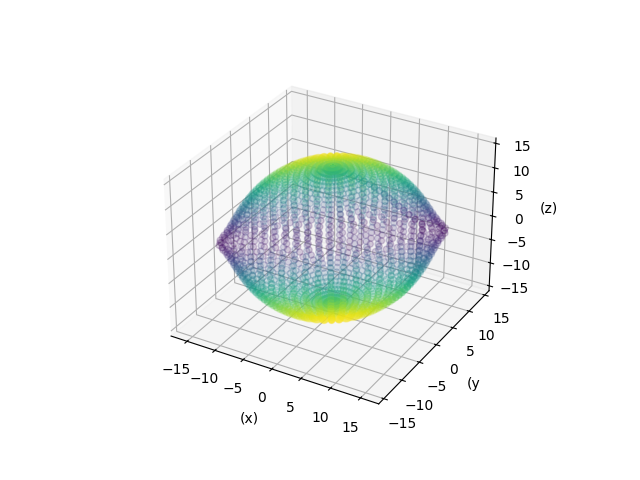

In [20]:
%matplotlib widget
idx=60
cm=plt.get_cmap('viridis',100)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
scale=vec/np.log10(T[:,idx].T)
#scale=vec*T[:,idx].T

ax.scatter(*scale,c=cm(T[:,idx]/np.max(T[:,idx])),alpha=0.2)

#ax.scatter(*(-Bnsym.T),c=cm(T[:,1]/np.max(T[:,1])),alpha=0.2)

#ax.plot_surface(*bpts.T,alpha=0.2)
# #ax.scatter(*bsph.T)
# ax.set_xlim(-Bf,Bf)
# ax.set_ylim(-Bf,Bf)
# ax.set_zlim(-Bf,Bf)

ax.set_xlabel("(x)")
ax.set_ylabel(r"(y")
ax.set_zlabel(r"(z)")

plt.show()


C:\Users\neb16\AppData\Local\Temp/ipykernel_27348/1600411724.py:35: ComplexWarning:

Casting complex values to real discards the imaginary part

C:\Users\neb16\AppData\Local\Temp/ipykernel_27348/1600411724.py:36: ComplexWarning:

Casting complex values to real discards the imaginary part



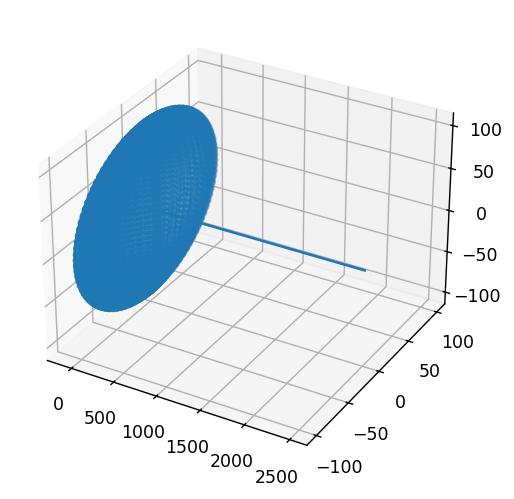

In [8]:
%matplotlib inline
plt.close()
unit=scale#/np.sqrt(np.sum(np.square(scale),axis=0))

Bs=unit.T#np.linspace(0,1E-3,500)
#Bu=np.matrix([0,1,1]).T
FSG=np.zeros((len(Bs),ground.dim))
FSE=np.zeros((len(Bs),excited.dim))
Ts=np.zeros((len(Bs),excited.dim*ground.dim))
#Ts=np.zeros((len(Bs),excited.dim**2))


FpG=np.zeros((len(Bs),ground.dim,3))
FpE=np.zeros((len(Bs),excited.dim,3))
Tps=np.zeros((len(Bs),excited.dim*ground.dim,3))
#Tps=np.zeros((len(Bs),excited.dim,3))


for i,x in enumerate(Bs):
    B = x            
    HG = ground.calcH(B)
    HE = excited.calcH(B)
 
    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    FSG[i,:]=FG#*1E3

    FE,VE = excited.getEigFreq(HE)
    FSE[i,:]=FE#*1E3
    
    Ts[i,:]=spin.eachElemFunc(FG,FE)
    #Ts[i,:]=spin.eachElemFunc(FE,FE)

    for j in range(3):
        FpG[i,:,j]= ground.firstOrderEnergySensitivity(VG,Ag[j])
        FpE[i,:,j]= excited.firstOrderEnergySensitivity(VE,Ae[j])
    Tps[i,:,:]=spin.eachElemFunc(FpG[i,:,:],FpE[i,:,:],ax=0)
    #Tps[i,:,:]=spin.eachElemFunc(FpE[i,:,:],FpE[i,:,:],ax=0)
    
    #Tps[i,:,:]=FpE[i,:,:]-FpG[i,0,:]

plt.plot(np.arange(0,Ts.shape[0],1),Ts[:,idx])
#plt.plot(Bs,FSE)
plt.show()
plt.close()

# print(VG)
# print(np.linalg.eigh(HG))